# Comandos para realização do trabalho da matéria de NLP com uso da biblioteca SKlearn e NLTK.

## <font color=red>Observação importante:</font>

<font color=yellow>Trabalho realizado com uso de corpus diferente do Fake.br não será aceito!</font>

**Aluno:** Guilherme Henrique Rodrigues da Silva  
**RU:** 4840505

Versão preenchida a partir do modelo do professor. Execute as células em ordem. No Colab, salve uma cópia no Drive. As nuvens são calculadas pelo código; não são imagens fixas.

## Carregando arquivos `pre-processed.csv`, de imagem e de funções auxiliares para dentro do Google Colab

In [1]:
# RU 4840505 — arquivos do mesmo modelo do professor
from pathlib import Path
import importlib.metadata as metadata
import subprocess
import sys

# Instala apenas bibliotecas ausentes, sem substituir o NumPy já instalado.
for pacote in ["requests", "pandas", "nltk", "scikit-learn", "wordcloud", "matplotlib", "Pillow"]:
    try:
        metadata.version(pacote)
    except metadata.PackageNotFoundError:
        subprocess.run([sys.executable, "-m", "pip", "install", pacote], check=True)

import requests
COMMIT_CORPUS = "780f5516c4ae070761632d98ac3368f3ded09d35"
COMMIT_DISCIPLINA = "7a47f6c1ce0f4e7565756215426ad6bf9aab4e85"
base_corpus = f"https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/{COMMIT_CORPUS}"
base_aula = f"https://raw.githubusercontent.com/N-CPUninter/NLP/{COMMIT_DISCIPLINA}"
arquivos = {
    "pre-processed.csv": base_corpus + "/preprocessed/pre-processed.csv",
    "funcoes_auxiliares.py": base_aula + "/funcoes_auxiliares.py",
    "data/img/thumbs_up_mask.png": base_aula + "/data/img/thumbs_up_mask.png",
    "data/img/thumbs_down_mask.png": base_aula + "/data/img/thumbs_down_mask.png",
}
for nome, url in arquivos.items():
    destino = Path(nome)
    if not destino.exists():
        resposta = requests.get(url, timeout=120)
        resposta.raise_for_status()
        destino.parent.mkdir(parents=True, exist_ok=True)
        destino.write_bytes(resposta.content)
    print("Arquivo pronto:", nome)


Arquivo pronto: pre-processed.csv
Arquivo pronto: funcoes_auxiliares.py
Arquivo pronto: data/img/thumbs_up_mask.png
Arquivo pronto: data/img/thumbs_down_mask.png


## Importações, identificação e stopwords
Execute depois da célula de arquivos. Se alguma biblioteca tiver acabado de ser instalada e a importação falhar, reinicie o kernel/sessão e execute novamente em ordem. Não baixamos `nltk.download("all")`: o exercício precisa somente das stopwords em português.

In [2]:
# RU 4840505 — importações e configuração
from pathlib import Path
import io
import zipfile
import random
import requests
import importlib.metadata as metadata
import json
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from wordcloud import WordCloud
from matplotlib.colors import ListedColormap
from IPython.display import display

ru_4840505 = "4840505"
SEMENTE = 42
SAIDA = Path("resultados_4840505")
SAIDA.mkdir(exist_ok=True)
from nltk import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from funcoes_auxiliares import gerar_nuvem_palavras

try:
    palavras_comuns = stopwords.words("portuguese")
except LookupError:
    url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/stopwords.zip"
    resposta = requests.get(url, timeout=60)
    resposta.raise_for_status()
    pasta = Path.home() / "nltk_data"
    destino = pasta / "corpora" / "stopwords"
    destino.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(resposta.content)) as arquivo:
        (destino / "portuguese").write_bytes(arquivo.read("stopwords/portuguese"))
    if str(pasta) not in nltk.data.path:
        nltk.data.path.insert(0, str(pasta))
    palavras_comuns = stopwords.words("portuguese")

versoes_4840505 = {p: metadata.version(p) for p in
    ["nltk", "scikit-learn", "pandas", "numpy", "wordcloud", "matplotlib"]}
print("RU:", ru_4840505)
print("Stopwords prontas:", len(palavras_comuns))
print("Bibliotecas:", versoes_4840505)


RU: 4840505
Stopwords prontas: 207
Bibliotecas: {'nltk': '3.10.3', 'scikit-learn': '1.8.0', 'pandas': '2.2.3', 'numpy': '2.3.5', 'wordcloud': '1.9.6', 'matplotlib': '3.10.8'}


## Criar dataframe do CSV utilizando o método read_csv do pandas

In [3]:
# RU 4840505 — leitura do CSV indicado pelo professor
df = pd.read_csv("pre-processed.csv")
assert len(df) == 7200
assert df["preprocessed_news"].notna().all()
assert df["label"].value_counts().to_dict() == {"fake": 3600, "true": 3600}

# O CSV oficial contém 3.600 falsas, seguidas das 3.600 verdadeiras,
# na mesma ordem lexicográfica dos arquivos originais em cada classe.
# A numeração original tem duas lacunas: 697 e 1468.
# Reconstruímos a ordem dos identificadores do commit fixado.
assert df["label"].tolist() == ["fake"] * 3600 + ["true"] * 3600
ids_pares = sorted((n for n in range(1, 3603) if n not in {697, 1468}), key=str)
assert len(ids_pares) == 3600
df["par"] = np.tile(ids_pares, 2)
df["classe"] = df["label"].map({"fake": "FAKE", "true": "REAL"})
df["texto"] = df["preprocessed_news"]
df = df.sort_values(["par", "classe"]).reset_index(drop=True)
assert df.groupby("par")["classe"].nunique().eq(2).all()
print("Notícias por classe:", df["classe"].value_counts().to_dict())
print(df[["par", "classe", "texto"]].head(2).to_string(index=False, max_colwidth=75))


Notícias por classe: {'FAKE': 3600, 'REAL': 3600}
 par classe                                                                       texto
   1   FAKE katia abreu diz vai colocar expulsao moldura nao reclamar senadora katia...
   1   REAL podemos decidiu expulsar deputado federal carlos gaguim partido apos pol...


# PRÁTICA 1 - CRIAÇÃO DE MODELO DE CLASSIFICAÇÃO SUPERVISIONADO PARA ANÁLISE DE FAKE NEWS.

1. Realize os seguintes procedimentos de limpeza dos textos do dataframe criado:

  1.1. Tokenizar

  1.2. Retirar os acentos e números

  1.3. Deixar tudo em minúsculas

  1.4. Retirar as stopwords e pontuações

  1.5. Deixar palavras apenas com radical (STEM)

  1.6. Realizar truncamento dos pares de notícias verdadeiras com falsas para normalizar quantidade de palavras

  1.7. Remontar as notícias em string e criar coluna no dataframe para o resultado deste pré-processamento.

2. Criar matriz de frequências TF-IDF com ngramas de 1 a 3 palavras.

3. Usar a função train_test_split do Scikit Learn para dividir o corpus pré-tratado em 75% dos textos para treinamento e 25% para testes de precisão (usar random_state = 42 ou outro número de sua escolha).

4. Fazer regressão logística com solver = 'lbfgs'.

5. Realizar predição dos textos de teste com o método predict_proba, que retornará a porcentagem predita para fake e para real em um array.

6. Por fim, com as porcentagens calculadas para cada texto de teste, usar a função accuracy_score da biblioteca Scikit Learn para calcular a acurácia geral do algoritmo.

### Limpeza e truncamento dos pares

In [4]:
# RU 4840505 — pré-processamento com NLTK
def retirar_acentos(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto)
                   if unicodedata.category(c) != "Mn")

stop_pt = {retirar_acentos(p) for p in stopwords.words("portuguese")}
stemmer = SnowballStemmer("portuguese")

def limpar(texto):
    texto = retirar_acentos(texto.lower())
    tokens = nltk.regexp_tokenize(texto, r"[a-z]+")
    return [stemmer.stem(p) for p in tokens
            if p not in stop_pt and len(p) > 1]

df["tokens"] = df["texto"].apply(limpar)
df["n_antes"] = df["tokens"].str.len()
df["n_depois"] = df.groupby("par")["n_antes"].transform("min")
df["tratado"] = [" ".join(t[:n])
                  for t, n in zip(df["tokens"], df["n_depois"])]
assert df["n_depois"].gt(0).all()
assert df.groupby("par")["n_depois"].nunique().eq(1).all()
balanco = df.groupby("classe")[["n_antes", "n_depois"]].sum()
assert balanco["n_depois"].nunique() == 1
print("Tokens após limpeza, antes e depois do truncamento:")
print(balanco)
print("Exemplo tratado:", df.loc[0, "tratado"][:85])

Tokens após limpeza, antes e depois do truncamento:
        n_antes  n_depois
classe                   
FAKE     369402    363435
REAL    2141998    363435
Exemplo tratado: kat abreu diz vai coloc expulsa moldur reclam senador kat abreu diss expulsa pmdb res


### Divisão 75/25 e TF-IDF (1 a 3 palavras)

In [5]:
# RU 4840505 — divisão por pares e vetorização
pares = sorted(df["par"].unique())
pares_treino, pares_teste = train_test_split(
    pares, test_size=0.25, random_state=SEMENTE)
treino = df[df["par"].isin(pares_treino)].copy()
teste = df[df["par"].isin(pares_teste)].copy()
assert set(pares_treino).isdisjoint(pares_teste)
assert not (set(treino["tratado"]) & set(teste["tratado"]))
assert len(treino) == 5400 and len(teste) == 1800

vetor = TfidfVectorizer(
    ngram_range=(1, 3), min_df=2, max_df=0.95,
    sublinear_tf=True, token_pattern=r"(?u)\b\w+\b")
X_treino = vetor.fit_transform(treino["tratado"])
X_teste = vetor.transform(teste["tratado"])
y_treino = treino["classe"].to_numpy()
y_teste = teste["classe"].to_numpy()
print("Treino:", treino["classe"].value_counts().to_dict())
print("Teste:", teste["classe"].value_counts().to_dict())
print("Vocabulário do modelo:", X_treino.shape[1], "termos")

Treino: {'FAKE': 2700, 'REAL': 2700}
Teste: {'FAKE': 900, 'REAL': 900}
Vocabulário do modelo: 91678 termos


### Regressão logística e predict_proba

In [6]:
# RU 4840505 — treinamento e avaliação
modelo = LogisticRegression(
    C=5.0, solver="lbfgs", max_iter=1000, random_state=SEMENTE)
modelo.fit(X_treino, y_treino)
probabilidades = modelo.predict_proba(X_teste)
predicoes = modelo.classes_[probabilidades.argmax(axis=1)]
acuracia = accuracy_score(y_teste, predicoes)
acertos = int((predicoes == y_teste).sum())
matriz = confusion_matrix(y_teste, predicoes, labels=["FAKE", "REAL"])
assert acertos / len(y_teste) == acuracia
assert acuracia > 0.85, "Rever o modelo: acurácia abaixo da meta."
print(f"RU {ru_4840505} | ACURÁCIA: {acuracia:.2%}")
print(f"Acertos: {acertos} de {len(y_teste)} notícias")
print("Matriz: linhas = classe real; colunas = classe prevista")
print(pd.DataFrame(matriz, index=["FAKE", "REAL"],
                   columns=["FAKE", "REAL"]))

RU 4840505 | ACURÁCIA: 91.72%
Acertos: 1651 de 1800 notícias
Matriz: linhas = classe real; colunas = classe prevista
      FAKE  REAL
FAKE   820    80
REAL    69   831


### Dicionários de pesos e contagens por classe

In [7]:
# RU 4840505 — contagens e pesos do treino
termos = vetor.get_feature_names_out()
ordem = np.array([len(t.split()) for t in termos])
pesos_por_classe = {}
contagens = {}
for classe in ["REAL", "FAKE"]:
    pesos = np.asarray(X_treino[y_treino == classe].sum(axis=0)).ravel()
    presentes = pesos > 0
    contagens[classe] = {
        "unigramas": int((presentes & (ordem == 1)).sum()),
        "bigramas": int((presentes & (ordem == 2)).sum()),
        "trigramas": int((presentes & (ordem == 3)).sum()),
    }
    pesos_por_classe[classe] = {
        termo: float(peso) for termo, peso in zip(termos, pesos)
        if peso > 0
    }
print("RU", ru_4840505, "| Termos distintos presentes no treino:")
print(pd.DataFrame(contagens).T)
print("Os termos são radicais após stemming.")

RU 4840505 | Termos distintos presentes no treino:
      unigramas  bigramas  trigramas
REAL      10163     43667      13756
FAKE      10200     45716      14320
Os termos são radicais após stemming.


### Nuvens com a função auxiliar do professor
O dicionário contém a soma dos pesos TF-IDF dos textos de treino da classe. A função oficial recebe esses pesos e a máscara indicada. O RU é acrescentado à figura antes de mostrá-la e salvá-la.

In [8]:
# RU 4840505 — função auxiliar oficial, com identificação da figura
def mostrar_nuvem(classe, mascara):
    mostrar = plt.show
    plt.show = lambda *args, **kwargs: None
    random.seed(SEMENTE)
    np.random.seed(SEMENTE)
    try:
        nuvem, total = gerar_nuvem_palavras(
            dicionario_tokens_e_frequencia=pesos_por_classe[classe],
            arquivo_mascara=mascara)
    finally:
        plt.show = mostrar
    fig = plt.gcf()
    fig.suptitle(f"{classe} | TF-IDF do treino | RU {ru_4840505}", fontsize=18)
    fig.text(0.5, 0.04, "Termos após stemming: tamanho indica o peso TF-IDF", ha="center")
    fig.savefig(SAIDA / f"nuvem_{classe.lower()}_4840505.png",
                dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)


## QUESTÃO 01: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos VERDADEIROS.

1. Formate seus dados usados para o treinamento do seu modelo em um dicionário de tokens e suas frequências.
2. Separe os dados em um grupo com textos marcados como verdadeiros e outro com os falsos.
3. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras


QUESTÃO 1 | REAL | RU 4840505
Termos distintos: {'unigramas': 10163, 'bigramas': 43667, 'trigramas': 13756}
Acurácia no teste: 91.72%
   * Um total de 67586 tokens foram computadas a partir do conjunto de dados.



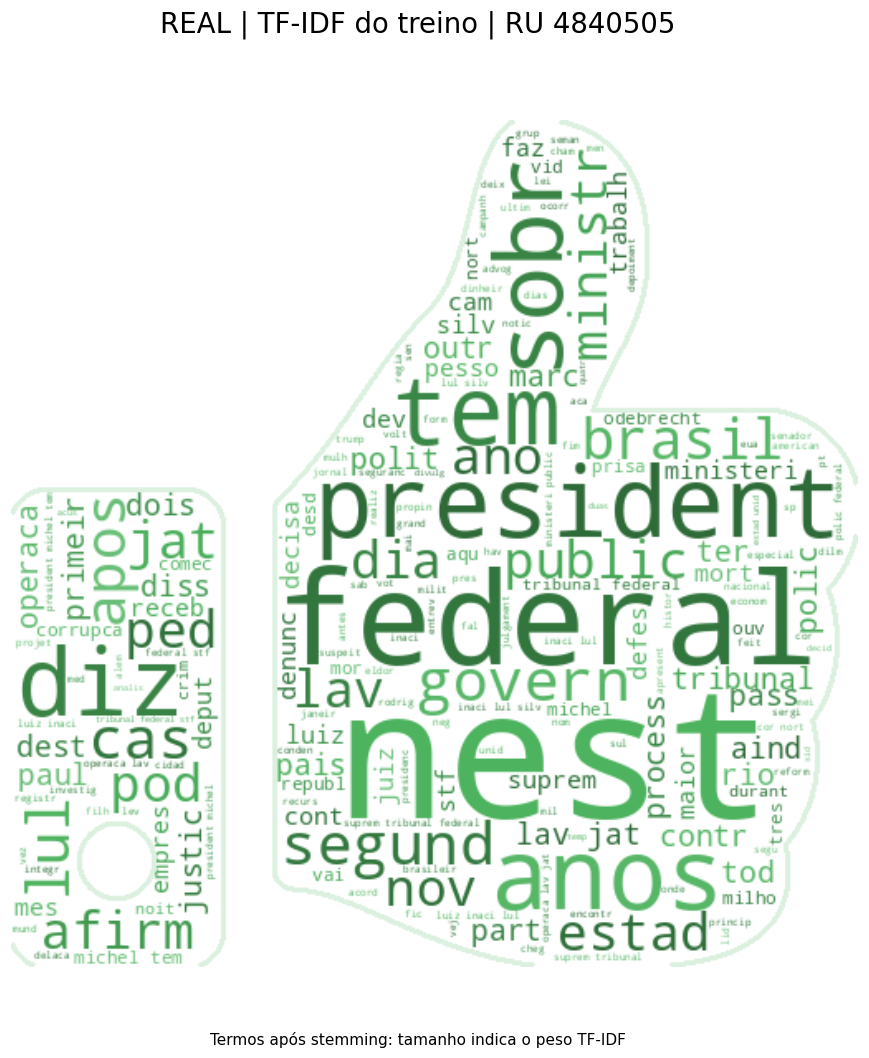

In [9]:
# RU 4840505 — resposta e nuvem da questão 1
print("QUESTÃO 1 | REAL | RU", ru_4840505)
print("Termos distintos:", contagens["REAL"])
print(f"Acurácia no teste: {acuracia:.2%}")
mostrar_nuvem("REAL", "thumbs_up_mask.png")

## QUESTÃO 02: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos FALSOS.

1. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_falsas, imagem de sua escolha) para gerar a nuvem de palavras

QUESTÃO 2 | FAKE | RU 4840505
Termos distintos: {'unigramas': 10200, 'bigramas': 45716, 'trigramas': 14320}
Limpeza: UTF-8, minúsculas, retirada de acentos, números
e pontuação; NLTK para tokens, stopwords e stemming;
truncamento por par; TF-IDF com n-gramas de 1 a 3.
Modelo: regressão logística, solver lbfgs, C=5.
   * Um total de 70236 tokens foram computadas a partir do conjunto de dados.



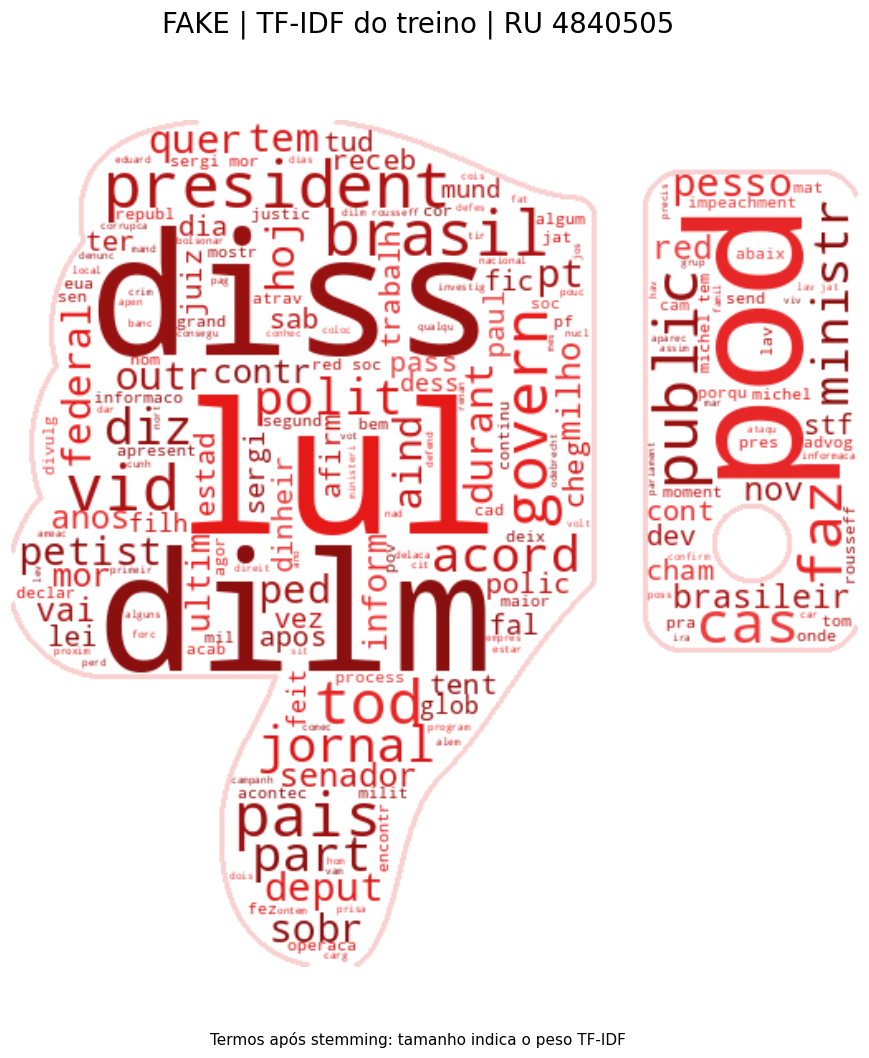

In [10]:
# RU 4840505 — resposta e nuvem da questão 2
print("QUESTÃO 2 | FAKE | RU", ru_4840505)
print("Termos distintos:", contagens["FAKE"])
print("Limpeza: UTF-8, minúsculas, retirada de acentos, números")
print("e pontuação; NLTK para tokens, stopwords e stemming;")
print("truncamento por par; TF-IDF com n-gramas de 1 a 3.")
print("Modelo: regressão logística, solver lbfgs, C=5.")
mostrar_nuvem("FAKE", "thumbs_down_mask.png")

---

# Material Complementar

## Alguns exemplos de uso da função auxiliar
`gerar_nuvem_palavras(dicionario_tokens_e_frequencia, arquivo_mascara)`

Gera uma nuvem de palavras com base em seu dicionário de palavras ou ngramas
    como a chave e a frequência de aparição do token como valor (inteiro).

    Parâmetros:
        dicionario_tokens_e_frequencia (dict): O dicionário de tokens e suas
                                               respectivas frequências de
                                               aparição nos textos.
        arquivo_mascara (str): O nome do arquivo da imagem de máscara. Pde ser:
                                            cloud_mask.png
                                            mapa_brasil_mask.png
                                            thumbs_up_mask.png        
                                            thumbs_down_mask.png
                                            <Outro arquivo de sua escolha>

    Exemplos de Uso:
        1. Para gerar uma nuvem de palavras na máscara mapa do brasil:
            gerar_nuvem_palavras(dicionario_tokens_e_frequencia=word_dict,
                                 arquivo_mascara='mapa_brasil_mask.png')

Os exemplos complementares do professor estão no [notebook original](https://colab.research.google.com/github/N-CPUninter/NLP/blob/main/trabalho_nlp.ipynb). Nesta cópia, as células das questões usam os dicionários efetivamente calculados pelo modelo, sem dados fictícios de exemplo.

## Salvar os resultados da execução

In [11]:
# RU 4840505 — registro dos resultados reais
resumo = {
    "ru": ru_4840505, "commit_corpus": COMMIT_CORPUS, "entrada": "pre-processed.csv",
    "acuracia": float(acuracia), "acertos": acertos,
    "n_treino": len(treino), "n_teste": len(teste),
    "vocabulario": len(termos), "contagens": contagens,
    "tokens_por_classe": balanco.to_dict(orient="index"),
    "matriz_confusao_fake_real": matriz.tolist(),
    "versoes": versoes_4840505,
}
(SAIDA / "resultados_4840505.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8")
df[["par", "classe", "n_antes", "n_depois"]].to_csv(
    SAIDA / "auditoria_tamanhos_4840505.csv", index=False)
print("Execução concluída | RU", ru_4840505)
print("Arquivos gerados em:", SAIDA.resolve())

Execução concluída | RU 4840505
Arquivos gerados em: /workspace/scratch/7c92b27d98e5/modelo_professor_4840505/resultados_4840505


## Entrega
1. No Colab, salve uma cópia no Drive e execute todas as células em ordem.
2. Confira acurácia acima de 85%, nuvens, contagens e RU.
3. Compartilhe sua cópia como leitor para qualquer pessoa com o link.
4. Use no caderno de resolução os resultados e prints desta versão. Os números e as nuvens da versão anterior podem mudar porque agora usamos o CSV indicado pelo professor.
5. Cole o link da sua cópia no caderno e exporte o PDF atualizado.

O classificador aprende padrões do corpus; sua acurácia não comprova a veracidade de uma notícia individual.